# Cross-Technology QC Metrics Comparison

Compare gene and guide mapping metrics across datasets.

**Input:** `latest_qc_paths.tsv`  
**Output:** Combined metrics TSVs and comparison barplots

In [9]:
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

In [10]:
# Project root
PROJECT_ROOT = Path("/cellar/users/aklie/data/datasets/tf_perturb_seq")

# Add config to path for color loader
sys.path.append(str(PROJECT_ROOT / "config"))
from loader import load_colors

dataset_colors = load_colors("technology-benchmark_WTC11_TF-Perturb-seq", "dataset_colors")
dataset_order = load_colors("technology-benchmark_WTC11_TF-Perturb-seq", "dataset_order")

In [26]:
# Paths
RUN_LABEL = "cleanser_unified"  # Change to "cleanser_unified" etc. to switch runs
BASE_DIR = PROJECT_ROOT / "datasets" / "technology-benchmark_WTC11_TF-Perturb-seq"
QC_PATHS_FILE = BASE_DIR / "manifests" / f"{RUN_LABEL}_qc_paths.tsv"
OUTPUT_DIR = BASE_DIR / "results" / "cross_tech_comparison" / RUN_LABEL
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Reading paths from: {QC_PATHS_FILE}")
print(f"Output directory: {OUTPUT_DIR}")

Reading paths from: /cellar/users/aklie/data/datasets/tf_perturb_seq/datasets/technology-benchmark_WTC11_TF-Perturb-seq/manifests/cleanser_unified_qc_paths.tsv
Output directory: /cellar/users/aklie/data/datasets/tf_perturb_seq/datasets/technology-benchmark_WTC11_TF-Perturb-seq/results/cross_tech_comparison/cleanser_unified


In [12]:
# Load the paths manifest
paths_df = pd.read_csv(QC_PATHS_FILE, sep="\t")
paths_df

,dataset,qc_dir,gene_metrics,guide_metrics,intended_target_results,intended_target_metrics,trans_results,trans_metrics
0,Hon_WTC11-benchmark_TF-Perturb-seq,/cellar/users/aklie/data/datasets/tf_perturb_s...,gene/gene_metrics.tsv,guide/guide_metrics.tsv,intended_target/intended_target_results.tsv,intended_target/intended_target_metrics.tsv,trans/trans_results.tsv,trans/trans_metrics.tsv
1,Huangfu_WTC11-benchmark_TF-Perturb-seq,/cellar/users/aklie/data/datasets/tf_perturb_s...,gene/gene_metrics.tsv,guide/guide_metrics.tsv,intended_target/intended_target_results.tsv,intended_target/intended_target_metrics.tsv,trans/trans_results.tsv,trans/trans_metrics.tsv
2,Gersbach_WTC11-benchmark_TF-Perturb-seq_GEM-Xv3,/cellar/users/aklie/data/datasets/tf_perturb_s...,gene/gene_metrics.tsv,guide/guide_metrics.tsv,intended_target/intended_target_results.tsv,intended_target/intended_target_metrics.tsv,trans/trans_results.tsv,trans/trans_metrics.tsv
3,Engreitz_WTC11-benchmark_TF-Perturb-seq,/cellar/users/aklie/data/datasets/tf_perturb_s...,gene/gene_metrics.tsv,guide/guide_metrics.tsv,intended_target/intended_target_results.tsv,intended_target/intended_target_metrics.tsv,trans/trans_results.tsv,trans/trans_metrics.tsv


## Gene Metrics

In [27]:
# Load and combine gene metrics
gene_metrics_list = []
for _, row in paths_df.iterrows():
    gene_path = Path(row['qc_dir']) / row['gene_metrics']
    if gene_path.exists():
        df = pd.read_csv(gene_path, sep="\t")
        df['dataset'] = row['dataset']
        gene_metrics_list.append(df)
    else:
        print(f"Warning: {gene_path} not found")

gene_metrics_df = pd.concat(gene_metrics_list, ignore_index=True)
gene_metrics_df.head()

,batch,n_cells,umi_median,umi_mean,umi_std,umi_min,umi_max,umi_q25,umi_q75,mito_median,mito_mean,mito_std,mito_min,mito_max,mito_q25,mito_q75,dataset
0,all,57775,4825.0,4820.2570,2394.4773,168.0,19969.0,3486.0,6232.0,5.347025,5.770274,2.779952,0.0,14.995811,3.980443,7.031372,Hon_WTC11-benchmark_TF-Perturb-seq
1,IGVFDS6244NAXC,24991,5279.0,5182.2570,2673.9626,168.0,19969.0,3765.0,6797.5,5.448872,5.719068,2.739825,0.0,14.995811,3.967706,7.088656,Hon_WTC11-benchmark_TF-Perturb-seq
2,IGVFDS8721BKRO,7255,3917.0,3778.9575,2399.1750,168.0,18175.0,1593.5,5399.5,5.714286,6.358837,3.496251,0.0,14.989940,4.067402,8.190243,Hon_WTC11-benchmark_TF-Perturb-seq
3,IGVFDS9613DDRB,25529,4655.0,4761.8090,1975.0972,168.0,19346.0,3585.0,5876.0,5.193561,5.653140,2.559951,0.0,14.995151,3.977467,6.723404,Hon_WTC11-benchmark_TF-Perturb-seq
4,all,141251,3856.0,3791.9300,2444.5752,277.0,24957.0,2112.0,5240.0,7.802875,8.011472,4.370673,0.0,19.993950,5.048543,10.363618,Huangfu_WTC11-benchmark_TF-Perturb-seq


In [28]:
# Save combined gene metrics
gene_metrics_df.to_csv(OUTPUT_DIR / "combined_gene_metrics.tsv", sep="\t", index=False)
print(f"Saved to {OUTPUT_DIR / 'combined_gene_metrics.tsv'}")

Saved to /cellar/users/aklie/data/datasets/tf_perturb_seq/datasets/technology-benchmark_WTC11_TF-Perturb-seq/results/cross_tech_comparison/cleanser_unified/combined_gene_metrics.tsv


In [29]:
# Filter to 'all' batch (aggregate metrics)
gene_all = gene_metrics_df[gene_metrics_df['batch'] == 'all'].copy()
gene_all['dataset'] = pd.Categorical(gene_all['dataset'], categories=dataset_order, ordered=True)
gene_all = gene_all.sort_values('dataset')
gene_all

,batch,n_cells,umi_median,umi_mean,umi_std,umi_min,umi_max,umi_q25,umi_q75,mito_median,mito_mean,mito_std,mito_min,mito_max,mito_q25,mito_q75,dataset
0,all,57775,4825.0,4820.2570,2394.4773,168.0,19969.0,3486.0,6232.0,5.347025,5.770274,2.779952,0.0,14.995811,3.980443,7.031372,Hon_WTC11-benchmark_TF-Perturb-seq
4,all,141251,3856.0,3791.9300,2444.5752,277.0,24957.0,2112.0,5240.0,7.802875,8.011472,4.370673,0.0,19.993950,5.048543,10.363618,Huangfu_WTC11-benchmark_TF-Perturb-seq
9,all,50993,26235.0,25302.5530,18802.1780,1044.0,167929.0,5673.0,37676.0,8.484267,9.069353,4.447468,0.0,19.998466,6.317479,11.469194,Gersbach_WTC11-benchmark_TF-Perturb-seq_GEM-Xv3
13,all,434062,1092.0,1334.5078,1283.9701,46.0,29219.0,119.0,1954.0,9.499395,10.049040,4.543291,0.0,19.997446,6.424623,13.461539,Engreitz_WTC11-benchmark_TF-Perturb-seq


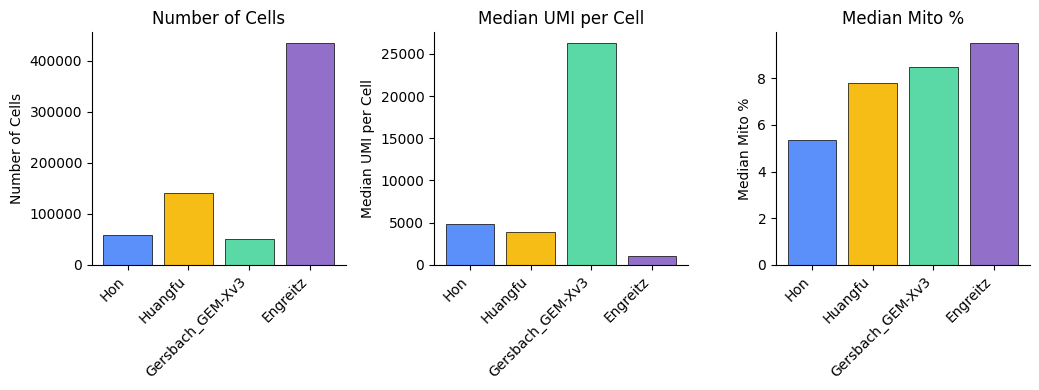

In [30]:
# Key gene metrics to compare (skip any not present in data)
gene_metrics_to_plot = [
    ('n_cells', 'Number of Cells'),
    ('umi_median', 'Median UMI per Cell'),
    ('genes_median', 'Median Genes per Cell'),
    ('mito_median', 'Median Mito %'),
]
gene_metrics_to_plot = [(col, title) for col, title in gene_metrics_to_plot if col in gene_all.columns]

fig, axes = plt.subplots(1, len(gene_metrics_to_plot), figsize=(3.5 * len(gene_metrics_to_plot), 4))
if len(gene_metrics_to_plot) == 1:
    axes = [axes]

for ax, (col, title) in zip(axes, gene_metrics_to_plot):
    colors = [dataset_colors.get(ds, 'gray') for ds in gene_all['dataset']]
    bars = ax.bar(range(len(gene_all)), gene_all[col], color=colors, edgecolor='black', linewidth=0.5)
    ax.set_xticks(range(len(gene_all)))
    ax.set_xticklabels([ds.replace('_WTC11-benchmark_TF-Perturb-seq', '') for ds in gene_all['dataset']], 
                       rotation=45, ha='right')
    ax.set_ylabel(title)
    ax.set_title(title)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "gene_metrics_comparison.pdf", dpi=300, bbox_inches='tight')
plt.show()

## Guide Metrics

In [31]:
# Load and combine guide metrics
guide_metrics_list = []
for _, row in paths_df.iterrows():
    guide_path = Path(row['qc_dir']) / row['guide_metrics']
    if guide_path.exists():
        df = pd.read_csv(guide_path, sep="\t")
        df['dataset'] = row['dataset']
        guide_metrics_list.append(df)
    else:
        print(f"Warning: {guide_path} not found")

guide_metrics_df = pd.concat(guide_metrics_list, ignore_index=True)
guide_metrics_df.head()

,batch,n_cells,guide_umi_median,guide_umi_mean,guide_umi_std,guide_umi_min,guide_umi_max,guide_umi_q25,guide_umi_q75,guides_per_cell_mean,...,n_cells_with_guide,n_cells_exactly_1_guide,frac_cells_with_guide,n_guides_total,cells_per_guide_median,cells_per_guide_mean,cells_per_guide_std,cells_per_guide_min,cells_per_guide_max,dataset
0,all,57775,799.0,1001.025720,871.062384,1.0,8285.0,308.0,1423.0,1.887148,...,56338,27412,0.975128,416.0,214.5,262.091346,271.302572,1.0,2049.0,Hon_WTC11-benchmark_TF-Perturb-seq
1,IGVFDS6244NAXC,24991,800.0,995.742107,880.186586,1.0,8285.0,272.0,1431.0,1.638790,...,23818,12714,0.953063,NaN,NaN,NaN,NaN,NaN,NaN,Hon_WTC11-benchmark_TF-Perturb-seq
2,IGVFDS8721BKRO,7255,516.0,776.835975,784.736293,1.0,7033.0,182.0,1132.0,2.617229,...,7135,3071,0.983460,NaN,NaN,NaN,NaN,NaN,NaN,Hon_WTC11-benchmark_TF-Perturb-seq
3,IGVFDS9613DDRB,25529,869.0,1069.909711,874.487143,6.0,7780.0,399.0,1489.0,1.922794,...,25385,11627,0.994359,NaN,NaN,NaN,NaN,NaN,NaN,Hon_WTC11-benchmark_TF-Perturb-seq
4,all,141251,99.0,215.444875,271.601295,1.0,4558.0,33.0,308.0,1.145698,...,107604,72094,0.761793,416.0,336.5,389.016827,434.979321,6.0,3826.0,Huangfu_WTC11-benchmark_TF-Perturb-seq


In [32]:
# Save combined guide metrics
guide_metrics_df.to_csv(OUTPUT_DIR / "combined_guide_metrics.tsv", sep="\t", index=False)
print(f"Saved to {OUTPUT_DIR / 'combined_guide_metrics.tsv'}")

Saved to /cellar/users/aklie/data/datasets/tf_perturb_seq/datasets/technology-benchmark_WTC11_TF-Perturb-seq/results/cross_tech_comparison/cleanser_unified/combined_guide_metrics.tsv


In [33]:
# Filter to 'all' batch (aggregate metrics)
guide_all = guide_metrics_df[guide_metrics_df['batch'] == 'all'].copy()
guide_all['dataset'] = pd.Categorical(guide_all['dataset'], categories=dataset_order, ordered=True)
guide_all = guide_all.sort_values('dataset')
guide_all

,batch,n_cells,guide_umi_median,guide_umi_mean,guide_umi_std,guide_umi_min,guide_umi_max,guide_umi_q25,guide_umi_q75,guides_per_cell_mean,...,n_cells_with_guide,n_cells_exactly_1_guide,frac_cells_with_guide,n_guides_total,cells_per_guide_median,cells_per_guide_mean,cells_per_guide_std,cells_per_guide_min,cells_per_guide_max,dataset
0,all,57775,799.0,1001.025720,871.062384,1.0,8285.0,308.0,1423.0,1.887148,...,56338,27412,0.975128,416.0,214.5,262.091346,271.302572,1.0,2049.0,Hon_WTC11-benchmark_TF-Perturb-seq
4,all,141251,99.0,215.444875,271.601295,1.0,4558.0,33.0,308.0,1.145698,...,107604,72094,0.761793,416.0,336.5,389.016827,434.979321,6.0,3826.0,Huangfu_WTC11-benchmark_TF-Perturb-seq
9,all,50993,430.0,943.872433,1244.500342,1.0,17324.0,52.0,1418.0,1.618850,...,46897,23840,0.919675,416.0,150.0,198.437500,239.281748,2.0,1926.0,Gersbach_WTC11-benchmark_TF-Perturb-seq_GEM-Xv3
13,all,434062,4.0,16.386813,39.851022,1.0,1020.0,2.0,8.0,0.309124,...,101507,75702,0.233854,416.0,294.0,322.545673,334.392955,1.0,3246.0,Engreitz_WTC11-benchmark_TF-Perturb-seq


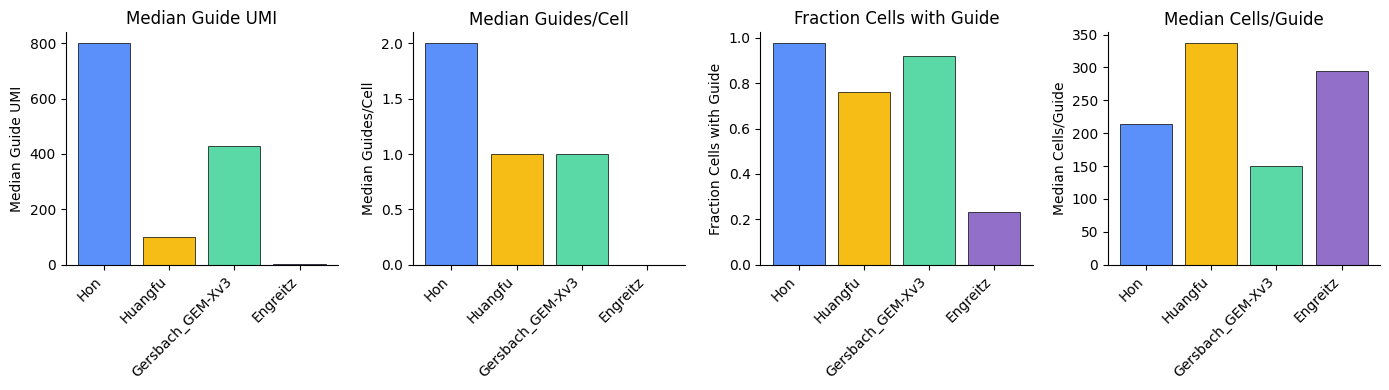

In [34]:
# Key guide metrics to compare
guide_metrics_to_plot = [
    ('guide_umi_median', 'Median Guide UMI'),
    ('guides_per_cell_median', 'Median Guides/Cell'),
    ('frac_cells_with_guide', 'Fraction Cells with Guide'),
    ('cells_per_guide_median', 'Median Cells/Guide'),
]

fig, axes = plt.subplots(1, len(guide_metrics_to_plot), figsize=(3.5 * len(guide_metrics_to_plot), 4))

for ax, (col, title) in zip(axes, guide_metrics_to_plot):
    colors = [dataset_colors.get(ds, 'gray') for ds in guide_all['dataset']]
    bars = ax.bar(range(len(guide_all)), guide_all[col], color=colors, edgecolor='black', linewidth=0.5)
    ax.set_xticks(range(len(guide_all)))
    ax.set_xticklabels([ds.replace('_WTC11-benchmark_TF-Perturb-seq', '') for ds in guide_all['dataset']], 
                       rotation=45, ha='right')
    ax.set_ylabel(title)
    ax.set_title(title)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "guide_metrics_comparison.pdf", dpi=300, bbox_inches='tight')
plt.show()

## Combined Summary Plot

In [35]:
# Create a combined summary with key metrics (only include gene cols present in data)
gene_summary_cols = ['dataset', 'n_cells', 'umi_median', 'mito_median']
if 'genes_median' in gene_all.columns:
    gene_summary_cols.insert(3, 'genes_median')

summary = gene_all[gene_summary_cols].merge(
    guide_all[['dataset', 'guide_umi_median', 'guides_per_cell_median', 'frac_cells_with_guide', 'cells_per_guide_median']],
    on='dataset'
)
summary

,dataset,n_cells,umi_median,mito_median,guide_umi_median,guides_per_cell_median,frac_cells_with_guide,cells_per_guide_median
0,Hon_WTC11-benchmark_TF-Perturb-seq,57775,4825.0,5.347025,799.0,2.0,0.975128,214.5
1,Huangfu_WTC11-benchmark_TF-Perturb-seq,141251,3856.0,7.802875,99.0,1.0,0.761793,336.5
2,Gersbach_WTC11-benchmark_TF-Perturb-seq_GEM-Xv3,50993,26235.0,8.484267,430.0,1.0,0.919675,150.0
3,Engreitz_WTC11-benchmark_TF-Perturb-seq,434062,1092.0,9.499395,4.0,0.0,0.233854,294.0


In [36]:
# Save summary
summary.to_csv(OUTPUT_DIR / "metrics_summary.tsv", sep="\t", index=False)
print(f"Saved to {OUTPUT_DIR / 'metrics_summary.tsv'}")

Saved to /cellar/users/aklie/data/datasets/tf_perturb_seq/datasets/technology-benchmark_WTC11_TF-Perturb-seq/results/cross_tech_comparison/cleanser_unified/metrics_summary.tsv


## Metrics by Lane

Compare metrics across individual lanes (batches) within each dataset.

In [37]:
# Get per-lane data (exclude 'all' aggregate)
gene_by_lane = gene_metrics_df[gene_metrics_df['batch'] != 'all'].copy()
guide_by_lane = guide_metrics_df[guide_metrics_df['batch'] != 'all'].copy()

# Add short dataset names for plotting
gene_by_lane['lab'] = gene_by_lane['dataset'].str.replace('_WTC11-benchmark_TF-Perturb-seq', '', regex=False)
guide_by_lane['lab'] = guide_by_lane['dataset'].str.replace('_WTC11-benchmark_TF-Perturb-seq', '', regex=False)

# Build gene column list dynamically
gene_lane_cols = ['batch', 'dataset', 'lab', 'n_cells', 'umi_median', 'mito_median']
if 'genes_median' in gene_by_lane.columns:
    gene_lane_cols.insert(5, 'genes_median')

# Merge gene and guide metrics by lane
lane_metrics = gene_by_lane[gene_lane_cols].merge(
    guide_by_lane[['batch', 'dataset', 'guide_umi_median', 'guides_per_cell_mean']],
    on=['batch', 'dataset'],
    how='left'
)

# Sort by dataset order then by batch
lane_metrics['dataset'] = pd.Categorical(lane_metrics['dataset'], categories=dataset_order, ordered=True)
lane_metrics = lane_metrics.sort_values(['dataset', 'batch']).reset_index(drop=True)
lane_metrics

,batch,dataset,lab,n_cells,umi_median,mito_median,guide_umi_median,guides_per_cell_mean
0,IGVFDS6244NAXC,Hon_WTC11-benchmark_TF-Perturb-seq,Hon,24991,5279.0,5.448872,800.0,1.638790
1,IGVFDS8721BKRO,Hon_WTC11-benchmark_TF-Perturb-seq,Hon,7255,3917.0,5.714286,516.0,2.617229
2,IGVFDS9613DDRB,Hon_WTC11-benchmark_TF-Perturb-seq,Hon,25529,4655.0,5.193561,869.0,1.922794
3,IGVFDS0471AYHF,Huangfu_WTC11-benchmark_TF-Perturb-seq,Huangfu,31056,3852.0,7.721316,109.0,1.249517
4,IGVFDS1260YCMC,Huangfu_WTC11-benchmark_TF-Perturb-seq,Huangfu,36948,3854.0,7.955339,102.0,1.125609
5,IGVFDS1889TBEY,Huangfu_WTC11-benchmark_TF-Perturb-seq,Huangfu,39331,3750.0,7.513228,85.0,1.087310
6,IGVFDS5642SPLX,Huangfu_WTC11-benchmark_TF-Perturb-seq,Huangfu,33916,3981.0,8.030819,102.0,1.140229
7,IGVFDS2155EXAM,Gersbach_WTC11-benchmark_TF-Perturb-seq_GEM-Xv3,Gersbach_GEM-Xv3,18348,25230.5,8.178795,268.0,1.556573
8,IGVFDS3517WZCL,Gersbach_WTC11-benchmark_TF-Perturb-seq_GEM-Xv3,Gersbach_GEM-Xv3,19588,25538.5,8.552536,255.0,1.555391
9,IGVFDS6100DRFR,Gersbach_WTC11-benchmark_TF-Perturb-seq_GEM-Xv3,Gersbach_GEM-Xv3,13057,27707.0,8.793264,1066.0,1.801562


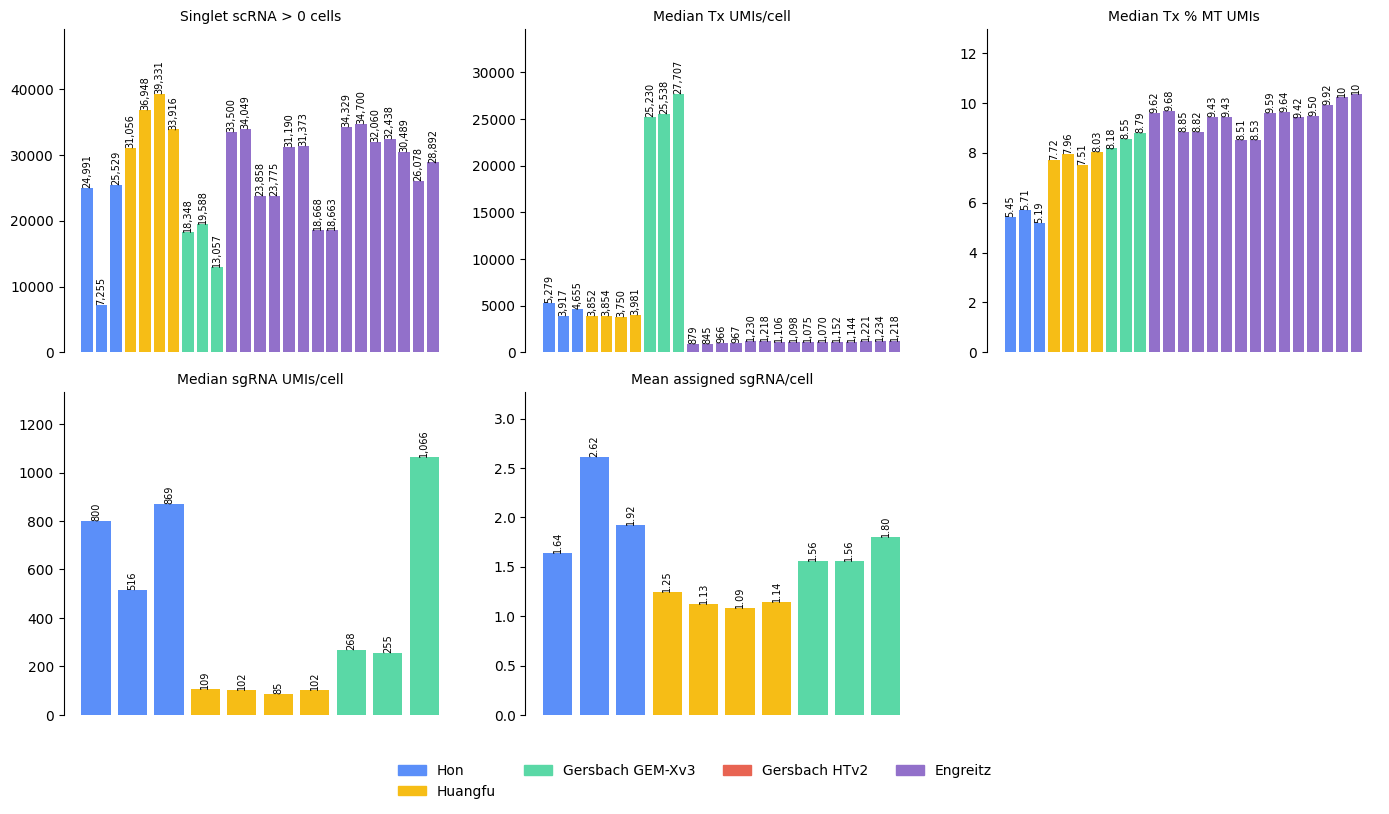

In [38]:
# Metrics to plot in 2x3 grid (matching example image); skip any not present in data
lane_metrics_to_plot = [
    ('n_cells', 'Singlet scRNA > 0 cells'),
    ('umi_median', 'Median Tx UMIs/cell'),
    ('genes_median', 'Median Tx\nExpressed Genes/cell'),
    ('mito_median', 'Median Tx % MT UMIs'),
    ('guide_umi_median', 'Median sgRNA UMIs/cell'),
    ('guides_per_cell_mean', 'Mean assigned sgRNA/cell'),
]
lane_metrics_to_plot = [(col, title) for col, title in lane_metrics_to_plot if col in lane_metrics.columns]

n_plots = len(lane_metrics_to_plot)
ncols = 3
nrows = int(np.ceil(n_plots / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4 * nrows))
axes = axes.flatten()

for ax, (col, title) in zip(axes, lane_metrics_to_plot):
    colors = [dataset_colors.get(ds, 'gray') for ds in lane_metrics['dataset']]
    x = np.arange(len(lane_metrics))
    bars = ax.bar(x, lane_metrics[col], color=colors, edgecolor='none', width=0.8)
    for i, (bar, val) in enumerate(zip(bars, lane_metrics[col])):
        if pd.notna(val):
            if val >= 1000:
                label = f'{val:,.0f}'
            elif val >= 10:
                label = f'{val:.0f}'
            else:
                label = f'{val:.2f}'
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(), label,
                   ha='center', va='bottom', fontsize=7, rotation=90)
    ax.set_xticks([])
    ax.set_title(title, fontsize=10)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ymax = lane_metrics[col].max()
    if pd.notna(ymax):
        ax.set_ylim(0, ymax * 1.25)

# Hide any unused axes
for ax in axes[n_plots:]:
    ax.set_visible(False)

legend_handles = [plt.Rectangle((0,0),1,1, color=dataset_colors[ds]) for ds in dataset_order]
legend_labels = [ds.replace('_WTC11-benchmark_TF-Perturb-seq', '').replace('_', ' ') for ds in dataset_order]
fig.legend(legend_handles, legend_labels, loc='lower center', ncol=4,
           bbox_to_anchor=(0.5, -0.02), frameon=False, fontsize=10)

plt.tight_layout()
plt.subplots_adjust(bottom=0.1)
plt.savefig(OUTPUT_DIR / "metrics_by_lane_comparison.pdf", dpi=300, bbox_inches='tight')
plt.show()

In [39]:
# Save lane metrics
lane_metrics.to_csv(OUTPUT_DIR / "metrics_by_lane.tsv", sep="\t", index=False)
print(f"Saved to {OUTPUT_DIR / 'metrics_by_lane.tsv'}")

Saved to /cellar/users/aklie/data/datasets/tf_perturb_seq/datasets/technology-benchmark_WTC11_TF-Perturb-seq/results/cross_tech_comparison/cleanser_unified/metrics_by_lane.tsv


---
# DONE!